**In this Notebook we will design the full graph using 3 tools: search_tool, RAG tool, and SQL-agent for travel database**

In [1]:
import os
from dotenv import load_dotenv
from pyprojroot import here
load_dotenv()

True

Set the environment variables

In [2]:
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")

### **1. initialize the Tools**

**1.1 RAG tool design**

In [3]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.tools import tool

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
VECTORDB_DIR = "data/airline_policy_vectordb"
K = 2

@tool
def lookup_policy(query: str)->str:
    """Consult the company policies to check whether certain options are permitted."""
    vectordb = Chroma(
    collection_name="rag-chroma",
    persist_directory=str(here(VECTORDB_DIR)),
    embedding_function=HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
    )
    docs = vectordb.similarity_search(query, k=K)
    return "\n\n".join([doc.page_content for doc in docs])

print(lookup_policy)

name='lookup_policy' description='Consult the company policies to check whether certain options are permitted.' args_schema=<class 'pydantic.v1.main.lookup_policySchema'> func=<function lookup_policy at 0x0000029B15CC5620>


Test the RAG tool

In [4]:
lookup_policy.invoke("can I cancel my ticket?")

f:\end_to_end_AI_Projects\QueryMind _ AI_Powered_Natural_Language_Interface_for_SQL_&_Vector_Databases\querymind\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2527.99it/s]
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


'hour cancellation policy that allows passengers to cancel their flights within 24 hours of booking at +1-877-507-7341\nwithout penalty . This policy applies to all fare types, including non-refundable tickets. If you cancel your Swiss Airlines\nflight within 24 hours of booking, you\'ll receive a full refund of your ticket price.\nHow to Cancel Swiss Airlines Flight within 24 Hours? If you need to cancel your Swiss Airlines flight within 24 hours of\nbooking, you can do so easily online. Here are the steps to follow:\nGo to Swiss Airlines\' website and click on the "Manage your bookings" tab. Enter your booking reference number and last\nname to access your booking. Select the flight you want to cancel and click on "Cancel flight." Confirm your cancellation\nand you\'ll receive a full refund of your ticket price. If you booked your Swiss Airlines flight through a travel agent, you\'ll\nneed to contact them directly to cancel your flight within 24 hours.\nImportant Things to Keep in Mi

**1.2 Search tool design**

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults

search_tool = TavilySearchResults(max_results=2)

Test the Search Tool

In [ ]:
search_tool.invoke("What's a 'node' in LangGraph?")

**1.3 SQL agent tool design**

In [6]:
from langchain_community.utilities import SQLDatabase
from langchain.chains import create_sql_query_chain
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_groq import ChatGroq

**SQL agent chain**

In [7]:
sqldb_directory = here("data/travel.sqlite")

sql_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
# llm = ChatGroq(model="llama-3.3-70b-versatile")
system_role = """Given the following user question, corresponding SQL query, and SQL result, answer the user question.\n
    Question: {question}\n
    SQL Query: {query}\n
    SQL Result: {result}\n
    Answer:
    """
db = SQLDatabase.from_uri(
    f"sqlite:///{sqldb_directory}")

execute_query = QuerySQLDataBaseTool(db=db)
write_query = create_sql_query_chain(
    sql_llm, db)
answer_prompt = PromptTemplate.from_template(
    system_role)


answer = answer_prompt | sql_llm | StrOutputParser()
chain = (
    RunnablePassthrough.assign(query=write_query).assign(
        result=itemgetter("query") | execute_query
    )
    | answer
)
# Test the chain
# message = "How many tables do I have in the database? and what are their names?"
# response = chain.invoke({"question": message})

@tool
def query_sqldb(query):
    """Query the Swiss Airline SQL Database and access all the company's information. Input should be a search query."""
    response = chain.invoke({"question": query})
    return response

In [ ]:
message = "How many tables do I have in the database? and what are their names?"
response = query_sqldb.invoke(message)
print(response)

**Wrap up the tools into a list**

In [8]:
tools = [search_tool, lookup_policy, query_sqldb]

#### **Load the LLM for the primary agent and bind it with the tools**

In [9]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
# Tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools)

### **2. Initialize the Graph State**

Define our StateGraph's state as a typed dictionary containing an append-only list of messages. These messages form the chat history, which is all the state our chatbot needs.

In [10]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

### **3. Define the Graph Nodes**

**3.1 First node: chatbot**

In [11]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

Next, we need to create a function that will run the tools when they are needed. To do this, we'll add the tools to a new node.

In the example below, we'll build a BasicToolNode. This node will check the latest message and, if it contains a request to use a tool, it will run the appropriate tool. This works because many language models (like Anthropic, OpenAI, and Google Gemini) support tool usage.

**3.2 Second node: BasicToolNode that runs the appropriate tool based on the primary agent's output**

In [12]:
import json
from langchain_core.messages import ToolMessage


class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[search_tool, lookup_policy, query_sqldb])
graph_builder.add_node("tools", tool_node)

### **4. Define the entry point and graph edges**

**Aproach 1**

In [ ]:
from typing import Literal


def route_tools(
    state: State,
) -> Literal["tools", "__end__"]:
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"



graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    
    {"tools": "tools", "__end__": "__end__"},
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

**Approach 2**

In [14]:
from langgraph.graph import END, MessagesState
from typing import Literal

# Define the function that determines whether to continue or not
def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    # If the LLM makes a tool call, then we route to the "tools" node
    if last_message.tool_calls:
        return "tools"
    # Otherwise, we stop (reply to the user)
    return END

graph_builder.add_conditional_edges(
    "chatbot",
    should_continue,
    ["tools", END],
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

### **5. Compile the graph**

- In this step, we can add a memory to our graph as well.

In [15]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

**5.1 Plot the compiled graph**

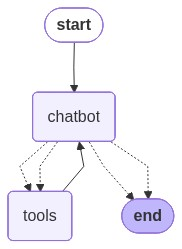

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

**Save the graph image**

In [17]:
save = False

if save:
    from PIL import Image as PILImage
    import io
    # Assuming graph.get_graph().draw_mermaid_png() returns PNG binary data
    try:
        # Generate the PNG image from the graph
        png_data = graph.get_graph().draw_mermaid_png()
        
        # Convert the binary data into an image
        img = PILImage.open(io.BytesIO(png_data))
        
        # Save the image locally with 300 DPI
        img.save('output_image.png', 'PNG', dpi=(300, 300))
        
        print("Image saved successfully with 300 DPI.")
    except Exception as e:
        print(f"Error: {e}")

### **6. Execute the graph**

In [18]:
config = {"configurable": {"thread_id": "1"}}

**First query**

Approach 1: Print all the steps the the system goes through it to get the final output

In [ ]:
user_input = "Hi there! My name is Farzad."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Farzad.


Approach 2: Just print the final output

In [55]:
from langchain_core.messages import HumanMessage
user_input = "Hi there! My name is Farzad."

# Use the Runnable
final_state = graph.invoke(
    {"messages": [HumanMessage(content=user_input)]},
    config=config
)
final_state["messages"][-1].content

'Hello again, Farzad! How can I help you today?'

**Second query**

In [56]:
user_input = "Can I cancel my ticket 10 hours before the flight?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Can I cancel my ticket 10 hours before the flight?
================================== Ai Message ==================================
Tool Calls:
  lookup_policy (call_PnEdkdZICkTDuytncfiYhJo2)
 Call ID: call_PnEdkdZICkTDuytncfiYhJo2
  Args:
    query: ticket cancellation policy
================================= Tool Message =================================
Name: lookup_policy

"for a refund or may only be able to receive a partial refund. If you booked your flight through a third-party website or\ntravel agent, you may need to contact them directly to cancel your flight. Always check the terms and conditions of your\nticket to make sure you understand the cancellation policy and any associated fees or penalties. If you're cancelling your\nflight due to unforeseen circumstances such as a medical emergency or a natural disaster , Swiss Air may of fer you\nspecial exemptions or accommodations. What is Swiss 

**Third query**

In [57]:
user_input = "Right now Harris vs. Trump Presidential Debate is being boradcasted. I want the youtube link to this debate"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Right now Harris vs. Trump Presidential Debate is being boradcasted. I want the youtube link to this debate
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_1jy65jCBXDpiaiDrn9n93HBC)
 Call ID: call_1jy65jCBXDpiaiDrn9n93HBC
  Args:
    query: Harris Trump Presidential Debate YouTube link
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.pbs.org/newshour/politics/watch-live-harris-and-trump-debate-pbs-news-simulcast-of-abcs-2024-presidential-debate", "content": "WATCH: Harris and Trump debate \u2014 PBS News simulcast of ABC\u2019s 2024 Presidential Debate Vice President Kamala Harris and former President Donald Trump faced off Tuesday night for their first and possibly only debate before Election Day. The state of the race as they meet in Phil

In [58]:
event

{'messages': [HumanMessage(content='Hi there! My name is Farzad.', id='5aa78bed-a259-4d29-91c0-0e00d4113895'),
  AIMessage(content='Hello Farzad! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 149, 'total_tokens': 161, 'prompt_tokens_details': {'cached_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f85bea6784', 'finish_reason': 'stop', 'logprobs': None}, id='run-6a8c7f6f-0647-4569-a1ff-58747953ad59-0', usage_metadata={'input_tokens': 149, 'output_tokens': 12, 'total_tokens': 161}),
  HumanMessage(content='Hi there! My name is Farzad.', id='45b30b4e-7aca-45f7-945d-48f4f3f738f0'),
  AIMessage(content='Hello again, Farzad! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 177, 'total_tokens': 191, 'prompt_tokens_detai